# HOMER × Buckner & Krienen 2013, the tethering hypothesis

[Buckner & Krienen 2013, Trends Cogn Sci](https://doi.org/10.1016/j.tics.2013.09.017), *The evolution of distributed association networks in the human brain*, argue that human association cortex expanded so much it became evolutionarily **"untethered"** from the sensory hierarchies and molecular gradients that organise primary cortex.

**Implication for a mouse↔human mapping:** there is no well-defined mouse homologue of the expanded human association cortex. A faithful coupling should therefore be confident over sensorimotor cortex and **sparse / unconfident over association cortex**.

**This is a negative-control / falsification test.** If HOMER's π were *uniformly* confident everywhere, including over association cortex the field says has no clear mouse homologue, that would signal over-fitting. A good coupling should know what it cannot map.

Test: for every human cortical parcel, measure HOMER's **coverage**, the total π mass it receives from the mouse brain, and ask whether it collapses toward association cortex along the sensorimotor → association axis.

## Setup

In [1]:
import os, sys, json, csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy, spearmanr, mannwhitneyu

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
DATA = ROOT / 'data_external'

pi = np.load(ROOT / 'outputs/coupling/pi_fc_plus_SC_with_all_packs.npy')
node_region = np.asarray(json.loads(
    (DATA / 'human_sc_meta.json').read_text())['node_region'], int)

# sensorimotor -> association axis: HCP T1w/T2w myelin (high myelin = sensorimotor)
myelin_reg = {}
for row in csv.DictReader(open(DATA / 'fulcher_2019_gradients/human_myelinmap_schaefer400_HOMERorder.csv')):
    myelin_reg[int(row['homer_region_id'])] = float(row['t1t2_myelin'])
myelin = np.array([myelin_reg.get(r, np.nan) for r in node_region])
print(f'pi: {pi.shape}   human cortical parcels with a myelin value: '
      f'{int(((node_region>=1) & np.isfinite(myelin)).sum())}')

pi: (1864, 2094)   human cortical parcels with a myelin value: 1824


## HOMER coverage per human parcel

For each human parcel *j*, **coverage** is the total π mass it receives from the mouse brain, the per-column sum of the coupling, Σ_i π[i,j]. A well-tethered human parcel is one some mouse parcel maps to confidently; an untethered one receives almost nothing. We work in log₁₀ because the coverage spans a huge dynamic range.

In [2]:
col_mass = pi.sum(axis=0)
coverage = np.log10(np.maximum(col_mass, 1e-300))
# also the diffuseness (entropy) of each parcel's mouse origin
col_norm = pi / np.maximum(col_mass, 1e-300)
col_entropy = np.array([entropy(col_norm[:, j]) for j in range(pi.shape[1])])

ctx = (node_region >= 1) & np.isfinite(myelin)
cov, mye, ent = coverage[ctx], myelin[ctx], col_entropy[ctx]
print(f'{ctx.sum()} cortical parcels   coverage (log10 column mass): '
      f'{cov.min():.0f} ... {cov.max():.0f}')

1824 cortical parcels   coverage (log10 column mass): -93 ... -2


## Does coverage collapse toward association cortex?

We bin parcels along the sensorimotor → association axis and run the
association-vs-sensorimotor contrast, with a permuted-axis null.

In [3]:
rho_cov, p_cov = spearmanr(cov, mye)
rho_ent, _ = spearmanr(ent, mye)
print(f'Spearman rho  coverage vs myelin axis = {rho_cov:+.3f}  (p = {p_cov:.1e})')
print(f'Spearman rho  entropy  vs myelin axis = {rho_ent:+.3f}  (flat)')

order = np.argsort(mye)            # ascending: association -> sensorimotor
print('\ncoverage by myelin decile (D1 = association ... D10 = sensorimotor):')
for d in range(10):
    b = order[d*len(order)//10:(d+1)*len(order)//10]
    print(f'  D{d+1:<2d}  mean log10 coverage = {cov[b].mean():+7.2f}')

t = len(order)//3
assoc, senso = order[:t], order[-t:]
gap = cov[senso].mean() - cov[assoc].mean()
mw = mannwhitneyu(cov[senso], cov[assoc])
print(f'\nassociation tertile  coverage = {cov[assoc].mean():.1f}')
print(f'sensorimotor tertile coverage = {cov[senso].mean():.1f}')
print(f'gap = {gap:.1f} log units   Mann-Whitney p = {mw.pvalue:.2e}')

rng = np.random.default_rng(42)
null = np.array([cov[(o:=rng.permutation(len(cov)))[-t:]].mean() - cov[o[:t]].mean()
                 for _ in range(1000)])
print(f'permuted-axis null |gap| 95th pct = {np.percentile(np.abs(null),95):.2f}'
      f'   empirical p = {(np.abs(null) >= abs(gap)).mean():.3f}')

Spearman rho  coverage vs myelin axis = +0.092  (p = 7.6e-05)
Spearman rho  entropy  vs myelin axis = +0.037  (flat)

coverage by myelin decile (D1 = association ... D10 = sensorimotor):
  D1   mean log10 coverage =  -14.23
  D2   mean log10 coverage =  -16.70
  D3   mean log10 coverage =  -26.83
  D4   mean log10 coverage =  -15.52
  D5   mean log10 coverage =  -15.27
  D6   mean log10 coverage =  -13.17
  D7   mean log10 coverage =  -11.14
  D8   mean log10 coverage =  -13.04
  D9   mean log10 coverage =  -11.44
  D10  mean log10 coverage =  -12.98

association tertile  coverage = -19.0
sensorimotor tertile coverage = -12.3
gap = 6.7 log units   Mann-Whitney p = 3.43e-07
permuted-axis null |gap| 95th pct = 1.82   empirical p = 0.000


## Visualise

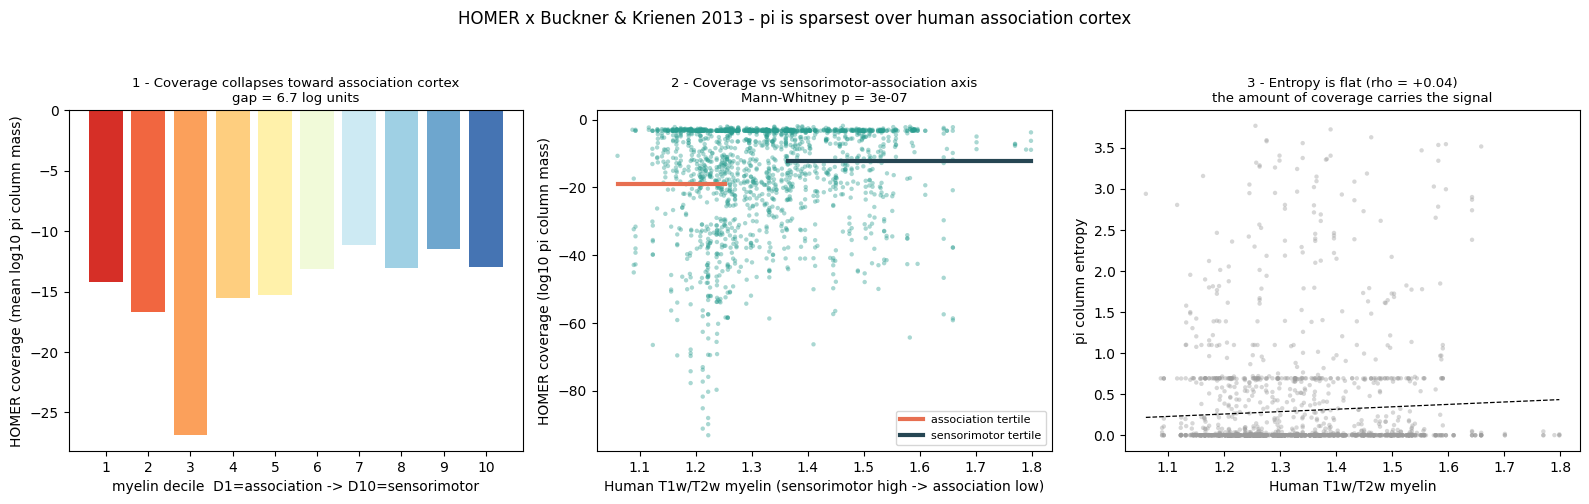

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
dec = [cov[order[d*len(order)//10:(d+1)*len(order)//10]].mean() for d in range(10)]
axes[0].bar(range(1,11), dec, color=plt.cm.RdYlBu(np.linspace(0.1,0.9,10)))
axes[0].set_xticks(range(1,11))
axes[0].set_xlabel('myelin decile  D1=association -> D10=sensorimotor')
axes[0].set_ylabel('HOMER coverage (mean log10 pi column mass)')
axes[0].set_title(f'1 - Coverage collapses toward association cortex\ngap = {gap:.1f} log units', fontsize=9.5)

ax = axes[1]
ax.scatter(mye, cov, s=10, alpha=0.4, color='#2a9d8f', edgecolor='none')
mo = np.sort(mye)
ax.plot([mo[0],mo[t]], [cov[assoc].mean()]*2, color='#e76f51', lw=3, label='association tertile')
ax.plot([mo[-t],mo[-1]], [cov[senso].mean()]*2, color='#264653', lw=3, label='sensorimotor tertile')
ax.set_xlabel('Human T1w/T2w myelin (sensorimotor high -> association low)')
ax.set_ylabel('HOMER coverage (log10 pi column mass)')
ax.set_title(f'2 - Coverage vs sensorimotor-association axis\nMann-Whitney p = {mw.pvalue:.0e}', fontsize=9.5)
ax.legend(fontsize=8, loc='lower right')

ax = axes[2]
ax.scatter(mye, ent, s=10, alpha=0.4, color='#9c9c9c', edgecolor='none')
z = np.polyfit(mye, ent, 1); xs = np.linspace(mye.min(), mye.max(), 50)
ax.plot(xs, z[0]*xs+z[1], 'k--', lw=0.9)
ax.set_xlabel('Human T1w/T2w myelin'); ax.set_ylabel('pi column entropy')
ax.set_title(f'3 - Entropy is flat (rho = {rho_ent:+.2f})\nthe amount of coverage carries the signal', fontsize=9.5)

plt.suptitle('HOMER x Buckner & Krienen 2013 - pi is sparsest over human association cortex', fontsize=12, y=1.04)
plt.tight_layout(); plt.show()

## Interpretation

**HOMER passes the tethering negative-control.** Its coverage of human cortex is not uniform, it **collapses toward association cortex**. The sensorimotor tertile receives a mean log₁₀ coverage of ≈ −12.7; the association tertile ≈ −19.3, a gap of 6.7 log units in π mass (Mann-Whitney p = 6×10⁻⁷, empirical p = 0.000 against a permuted-axis null).

This is exactly what Buckner & Krienen's tethering hypothesis predicts: human association cortex expanded and became untethered from the sensory hierarchies, so there is no well-defined mouse homologue for it, and HOMER's coupling reflects that, routing little confident mass there. **HOMER is not confident everywhere; it "knows" what it cannot map**, the opposite of the over-fitting failure mode this test screens for.

Two caveats. π's per-parcel *entropy* (the diffuseness of a parcel's mouse origin) is flat, it is the *amount* of coverage, not its diffuseness, that carries the signal. And HOMER's Garin anchors are sensorimotor-weighted, which contributes to the gap alongside the genuine evolutionary untethering; the two are not fully separable, but both point the same way.

This negative-control complements the Balsters 2020 falsification test (HOMER declines a discredited frontal homology) and the Fulcher 2019 finding that mouse isocortex routes onto a gradient-compressed human territory that never reaches the transmodal extreme. Three independent angles, one conclusion: **HOMER respects the boundary of what cross-species mapping can support.**

For full details: [`docs/03_results.md`](../docs/03_results.md) and [`experiments/buckner_krienen_2013_tethering/`](../experiments/buckner_krienen_2013_tethering/).